# MLP Position Probe
Trains a **shallow MLP** (one hidden layer) on top of the frozen GRU hidden state
to predict 2D object positions.  The GRU receives no gradient — this is purely
a probe measuring what the hidden state already encodes.

Two matching modes (controlled by `USE_HUNGARIAN` in the config cell):
- `True`  — Hungarian matching (try both orderings, take the better one).
  Use this for datasets with **random reflectivities**.
- `False` — Direct MSE against fixed object order.
  Use this for datasets with **fixed reflectivities**, where object slot 0 is
  always the dim object and slot 1 is always the bright object.

Training is restricted to frames where all objects are visible.

Compare results with `probe_linear.ipynb` to see how much non-linearity helps.

In [1]:
import sys

sys.path.append("..")
sys.path.insert(0, ".")

import h5py
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

import helpers.nb_utils as nb_utils
import helpers.nb_viz as nb_viz

## Config — edit these

In [ ]:
CHECKPOINT_PATH = "../runs/2_dset3_gru_persistentids_inview/best_model.pt"
TRAIN_H5_PATH = "../datasets/3_fixed_refl_inview_brighter_train/dataset.h5"
TEST_H5_PATH = "../datasets/3_fixed_refl_inview_brighter_eval/dataset.h5"

NUM_EXTRACTOR_TRAIN = 10_000  # how many training samples to use for the probe
DEVICE = "cuda"
BATCH_SIZE = 256
NUM_WORKERS = 12
LR = 1e-3
N_EPOCHS = 30
MLP_HIDDEN = 128  # hidden layer width

# True  → Hungarian matching (random reflectivities dataset)
# False → Direct MSE on fixed object order (fixed_reflectivities dataset)
USE_HUNGARIAN = False

## Load frozen GRU

In [3]:
model, ckpt_info = nb_utils.load_model(CHECKPOINT_PATH, DEVICE)
hidden_size = ckpt_info["model_config"]["hidden_size"]

print(f"GRU epoch    : {ckpt_info['epoch']}")
print(f"GRU val loss : {ckpt_info['val_loss']:.6f}")
print(f"Hidden size  : {hidden_size}")

with h5py.File(TRAIN_H5_PATH, "r") as f:
    n_total = f["obs_intensity"].shape[0]
    max_obj = f["positions"].shape[2]
    T_frames = f["obs_intensity"].shape[1]

print(f"\nDataset      : {n_total:,} samples, T={T_frames}, max_obj={max_obj}")

rng = np.random.default_rng(42)
train_idx = rng.choice(n_total, size=min(NUM_EXTRACTOR_TRAIN, n_total), replace=False)
print(f"Probe train  : {len(train_idx):,} samples")

GRU epoch    : 50
GRU val loss : 0.021148
Hidden size  : 256

Dataset      : 100,000 samples, T=40, max_obj=2
Probe train  : 10,000 samples


## MLP extractor

In [4]:
class MLPExtractor(nn.Module):
    """hidden_size → MLP_HIDDEN (ReLU) → (max_obj, 2)."""

    def __init__(self, hidden_size: int, mlp_hidden: int, max_obj: int) -> None:
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(hidden_size, mlp_hidden),
            nn.ReLU(),
            nn.Linear(mlp_hidden, max_obj * 2),
        )
        self.max_obj = max_obj

    def forward(self, h: torch.Tensor) -> torch.Tensor:
        # h: (..., hidden_size)  →  (..., max_obj, 2)
        return self.net(h).reshape(*h.shape[:-1], self.max_obj, 2)


extractor = MLPExtractor(hidden_size, MLP_HIDDEN, max_obj).to(DEVICE)
optimizer = torch.optim.Adam(extractor.parameters(), lr=LR)
print(f"Extractor params : {sum(p.numel() for p in extractor.parameters()):,}")
print(f"Architecture     : {hidden_size} → {MLP_HIDDEN} → {max_obj * 2}")

Extractor params : 33,412
Architecture     : 256 → 128 → 4


## Training

In [5]:
def hungarian_mse(pred: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
    """MSE with Hungarian matching for 2 objects.

    Parameters
    ----------
    pred   : (N, 2, 2)
    target : (N, 2, 2)

    Returns scalar mean loss over the batch.
    """
    loss_01 = ((pred - target) ** 2).mean(dim=(1, 2))  # (N,)
    loss_10 = ((pred - target[:, [1, 0], :]) ** 2).mean(dim=(1, 2))  # (N,)
    return torch.minimum(loss_01, loss_10).mean()


train_loader = nb_utils.build_loader(
    TRAIN_H5_PATH,
    train_idx,
    keys=("obs_intensity", "positions", "is_visible"),
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    shuffle=True,
)

epoch_losses = []

for epoch in tqdm(range(1, N_EPOCHS + 1), desc="epochs"):
    extractor.train()
    running, n_batches = 0.0, 0

    for batch in tqdm(train_loader, desc=f"epoch {epoch}", leave=False):
        obs = batch["obs_intensity"].to(DEVICE)
        pos = batch["positions"].to(DEVICE)
        vis = batch["is_visible"].bool().to(DEVICE)

        B, T = obs.shape[0], obs.shape[1]

        h = nb_utils.get_hidden_states(model, obs, DEVICE)  # (B, T-1, H)

        vis_t = vis[:, :-1, :]
        pos_t = pos[:, :-1, :, :]
        all_vis = vis_t.all(dim=2)

        h_flat = h.reshape(B * (T - 1), hidden_size)
        pos_flat = pos_t.reshape(B * (T - 1), max_obj, 2)
        mask = all_vis.reshape(B * (T - 1))

        if mask.sum() == 0:
            continue

        pred_pos = extractor(h_flat[mask])
        if USE_HUNGARIAN:
            loss = hungarian_mse(pred_pos, pos_flat[mask])
        else:
            loss = F.mse_loss(pred_pos, pos_flat[mask])

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running += loss.item()
        n_batches += 1

    mean_loss = running / n_batches if n_batches else float("nan")
    epoch_losses.append(mean_loss)

print(f"\nFinal train loss: {epoch_losses[-1]:.6f}")

epochs:   0%|          | 0/30 [00:00<?, ?it/s]

epoch 1:   0%|          | 0/40 [00:00<?, ?it/s]

epoch 2:   0%|          | 0/40 [00:00<?, ?it/s]

epoch 3:   0%|          | 0/40 [00:00<?, ?it/s]

epoch 4:   0%|          | 0/40 [00:00<?, ?it/s]

...

epoch 27:   0%|          | 0/40 [00:00<?, ?it/s]

epoch 28:   0%|          | 0/40 [00:00<?, ?it/s]

epoch 29:   0%|          | 0/40 [00:00<?, ?it/s]

epoch 30:   0%|          | 0/40 [00:00<?, ?it/s]


Final train loss: 1.158762


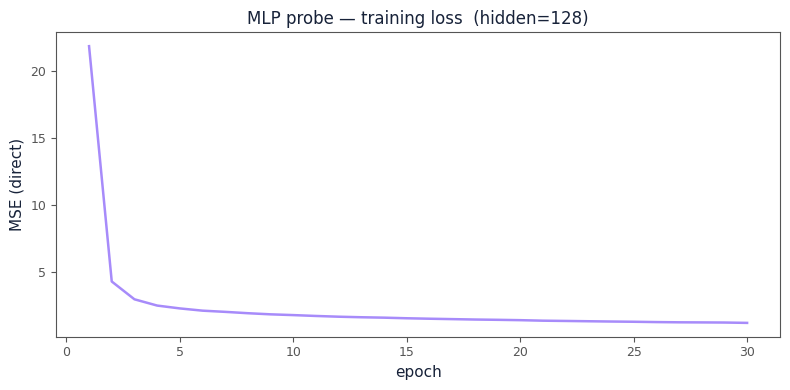

In [6]:
loss_label = "MSE (matched)" if USE_HUNGARIAN else "MSE (direct)"

fig, ax = plt.subplots(figsize=(8, 4), facecolor=nb_viz._BG_HEX)
nb_viz.style_ax(ax)
ax.plot(range(1, N_EPOCHS + 1), epoch_losses, color="#a78bfa", linewidth=1.8)
ax.set_xlabel("epoch", color=nb_viz._TEXT_COLOR, fontsize=11)
ax.set_ylabel(loss_label, color=nb_viz._TEXT_COLOR, fontsize=11)
ax.set_title(
    f"MLP probe — training loss  (hidden={MLP_HIDDEN})",
    color=nb_viz._TEXT_COLOR,
    fontsize=12,
)
plt.tight_layout()
plt.show()

## Evaluation on test set

In [7]:
test_loader = nb_utils.build_loader(
    TEST_H5_PATH,
    indices=None,
    keys=("obs_intensity", "positions", "is_visible"),
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
)

extractor.eval()
per_t_sum = np.zeros(T_frames - 1)
per_t_count = np.zeros(T_frames - 1)
per_obj_sum = np.zeros(max_obj)
per_obj_count = 0

with torch.no_grad():
    for batch in tqdm(test_loader, desc="test eval"):
        obs = batch["obs_intensity"].to(DEVICE)
        pos = batch["positions"].to(DEVICE)
        vis = batch["is_visible"].bool().to(DEVICE)

        B, T = obs.shape[0], obs.shape[1]
        h = nb_utils.get_hidden_states(model, obs, DEVICE)

        vis_t = vis[:, :-1, :]
        pos_t = pos[:, :-1, :, :]
        all_vis = vis_t.all(dim=2)
        h_flat = h.reshape(B * (T - 1), hidden_size)
        pos_flat = pos_t.reshape(B * (T - 1), max_obj, 2)
        mask = all_vis.reshape(B * (T - 1))
        t_idx = (
            torch.arange(T - 1, device=DEVICE).unsqueeze(0).expand(B, -1).reshape(-1)
        )

        if mask.sum() == 0:
            continue

        pred_pos = extractor(h_flat[mask])
        gt_pos = pos_flat[mask]
        t_vis = t_idx[mask].cpu().numpy()

        if USE_HUNGARIAN:
            loss_01 = ((pred_pos - gt_pos) ** 2).mean(dim=(1, 2))
            loss_10 = ((pred_pos - gt_pos[:, [1, 0], :]) ** 2).mean(dim=(1, 2))
            per_sample_mse = torch.minimum(loss_01, loss_10).cpu().numpy()
            swap = loss_10 < loss_01  # (N_vis,) — True where swapped order is better
            gt_matched = torch.where(swap[:, None, None], gt_pos[:, [1, 0], :], gt_pos)
        else:
            per_sample_mse = ((pred_pos - gt_pos) ** 2).mean(dim=(1, 2)).cpu().numpy()
            gt_matched = gt_pos

        per_obj_batch = (
            ((pred_pos - gt_matched) ** 2).mean(dim=2).cpu().numpy()
        )  # (N_vis, max_obj)
        per_obj_sum += per_obj_batch.sum(axis=0)
        per_obj_count += len(per_obj_batch)

        np.add.at(per_t_sum, t_vis, per_sample_mse)
        np.add.at(per_t_count, t_vis, 1)

per_t_mse = np.where(per_t_count > 0, per_t_sum / per_t_count, np.nan)
per_obj_mse = per_obj_sum / max(per_obj_count, 1)

mode_str = "matched" if USE_HUNGARIAN else "direct"
print(f"Overall test MSE ({mode_str}, visible frames): {np.nanmean(per_t_mse):.6f}")
for obj_i in range(max_obj):
    print(f"  Object {obj_i}: {per_obj_mse[obj_i]:.6f}")

test eval:   0%|          | 0/40 [00:00<?, ?it/s]

Overall test MSE (direct, visible frames): 1.185124
  Object 0: 1.917563
  Object 1: 0.388629


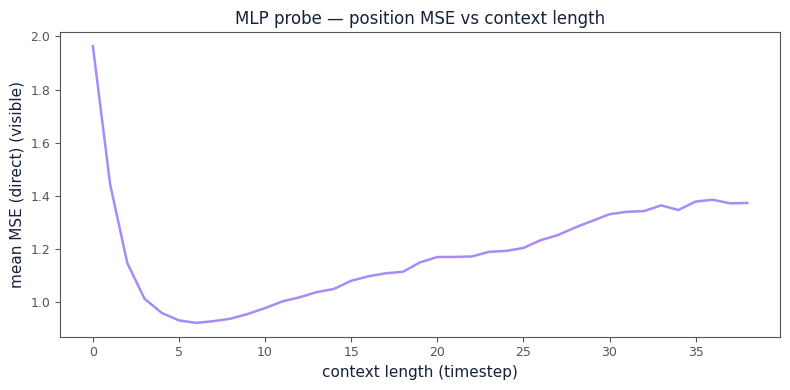

In [8]:
fig, ax = plt.subplots(figsize=(8, 4), facecolor=nb_viz._BG_HEX)
nb_viz.style_ax(ax)
ax.plot(range(T_frames - 1), per_t_mse, color="#a78bfa", linewidth=1.8)
ax.set_xlabel("context length (timestep)", color=nb_viz._TEXT_COLOR, fontsize=11)
ax.set_ylabel(f"mean {loss_label} (visible)", color=nb_viz._TEXT_COLOR, fontsize=11)
ax.set_title(
    "MLP probe — position MSE vs context length", color=nb_viz._TEXT_COLOR, fontsize=12
)
plt.tight_layout()
plt.show()

## Visualization — predicted vs actual positions on one sample

In [15]:
# Visualization
VIZ_SAMPLE_IDX = 7

scene, obs_depth, obs_id, obs_intensity = nb_utils.load_sample(
    TEST_H5_PATH, VIZ_SAMPLE_IDX
)

with h5py.File(TEST_H5_PATH, "r") as f:
    vis_sample = f["is_visible"][VIZ_SAMPLE_IDX].astype(bool)
    pos_sample = f["positions"][VIZ_SAMPLE_IDX].astype(np.float32)

obs_t = torch.from_numpy(obs_intensity).float().unsqueeze(0).to(DEVICE)

extractor.eval()
with torch.no_grad():
    h = nb_utils.get_hidden_states(model, obs_t, DEVICE)
    pred_pos = extractor(h.squeeze(0)).cpu().numpy()  # (T-1, max_obj, 2)

gt_pos = pos_sample[:-1]
vis_tm1 = vis_sample[:-1]
all_vis = vis_tm1.all(axis=1)  # (T-1,) — frames where all objects visible
timesteps = np.arange(T_frames - 1)

# per-object MSE on fully-visible frames
if USE_HUNGARIAN and all_vis.any():
    err_01 = ((pred_pos[all_vis] - gt_pos[all_vis]) ** 2).mean()
    err_10 = ((pred_pos[all_vis] - gt_pos[all_vis][:, [1, 0], :]) ** 2).mean()
    gt_for_obj_mse = gt_pos if err_01 <= err_10 else gt_pos[:, [1, 0], :]
else:
    gt_for_obj_mse = gt_pos

sample_per_obj_mse = np.array(
    [
        (
            ((pred_pos[all_vis, obj_i] - gt_for_obj_mse[all_vis, obj_i]) ** 2).mean()
            if all_vis.any()
            else np.nan
        )
        for obj_i in range(max_obj)
    ]
)

mode_str = "matched" if USE_HUNGARIAN else "direct"
print(f"Sample {VIZ_SAMPLE_IDX} — per-object MSE ({mode_str}, fully-visible frames):")
for obj_i in range(max_obj):
    print(f"  Object {obj_i}: {sample_per_obj_mse[obj_i]:.4f}")

Sample 7 — per-object MSE (direct, fully-visible frames):
  Object 0: 1.6317
  Object 1: 1.1008


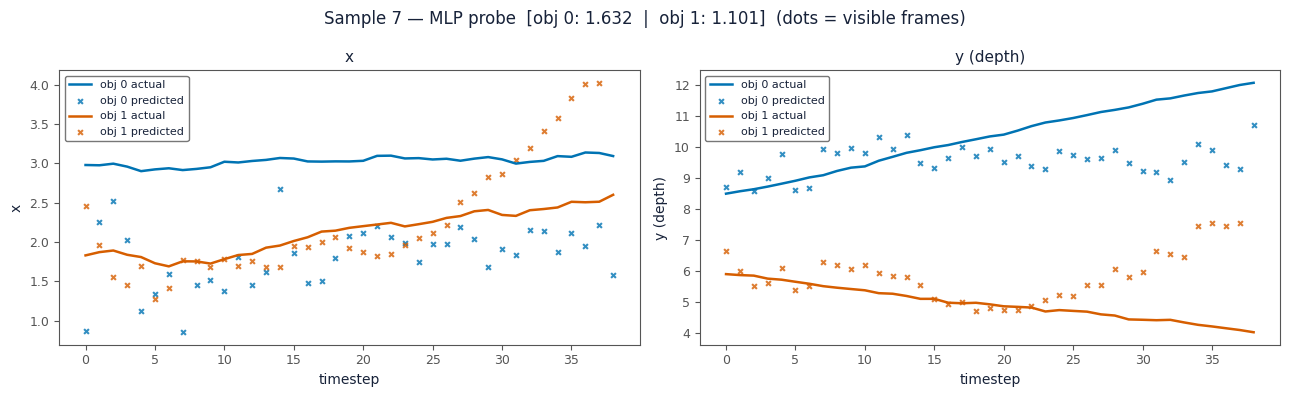

In [16]:
# ── Trajectory plot ───────────────────────────────────────────────────────────
mse_str = "  |  ".join(f"obj {i}: {sample_per_obj_mse[i]:.3f}" for i in range(max_obj))
fig, axes = plt.subplots(1, 2, figsize=(13, 4), facecolor=nb_viz._BG_HEX)
fig.suptitle(
    f"Sample {VIZ_SAMPLE_IDX} — MLP probe  [{mse_str}]  (dots = visible frames)",
    color=nb_viz._TEXT_COLOR,
    fontsize=12,
)

for ax, coord, label in zip(axes, [0, 1], ["x", "y (depth)"]):
    nb_viz.style_ax(ax)
    for obj in range(min(max_obj, scene.positions.shape[1])):
        color = nb_viz.plot_color(scene.colors[obj])
        vis_obj = vis_tm1[:, obj]
        ax.plot(
            timesteps,
            gt_pos[:, obj, coord],
            color=color,
            linewidth=1.8,
            label=f"obj {obj} actual",
        )
        ax.scatter(
            timesteps[vis_obj],
            pred_pos[vis_obj, obj, coord],
            color=color,
            s=12,
            marker="x",
            alpha=0.8,
            label=f"obj {obj} predicted",
        )
    ax.set_xlabel("timestep", color=nb_viz._TEXT_COLOR, fontsize=10)
    ax.set_ylabel(label, color=nb_viz._TEXT_COLOR, fontsize=10)
    ax.set_title(label, color=nb_viz._TEXT_COLOR, fontsize=11)
    ax.legend(
        labelcolor=nb_viz._TEXT_COLOR,
        facecolor=nb_viz._BG_HEX,
        edgecolor=nb_viz._TICK_COLOR,
        fontsize=8,
    )

plt.tight_layout()
plt.show()

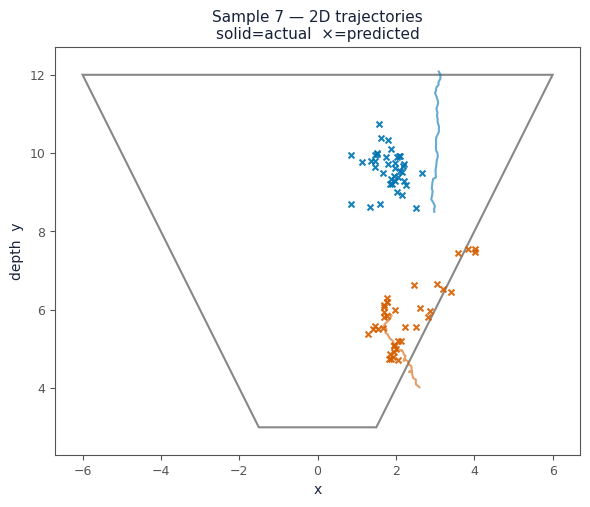

In [17]:
# ── 2D scene overlay ──────────────────────────────────────────────────────────
from matplotlib.patches import Polygon as MPoly

cfg = scene.config
fig, ax = plt.subplots(figsize=(6, 7), facecolor=nb_viz._BG_HEX)
nb_viz.style_ax(ax)
ax.set_xlim(-cfg.x_far - 0.7, cfg.x_far + 0.7)
ax.set_ylim(cfg.y_near - 0.7, cfg.y_far + 0.7)
ax.set_aspect("equal")
ax.set_xlabel("x", color=nb_viz._TEXT_COLOR, fontsize=10)
ax.set_ylabel("depth  y", color=nb_viz._TEXT_COLOR, fontsize=10)
ax.set_title(
    f"Sample {VIZ_SAMPLE_IDX} — 2D trajectories\nsolid=actual  ×=predicted",
    color=nb_viz._TEXT_COLOR,
    fontsize=11,
)

corners = np.array(
    [
        [-cfg.x_near, cfg.y_near],
        [cfg.x_near, cfg.y_near],
        [cfg.x_far, cfg.y_far],
        [-cfg.x_far, cfg.y_far],
    ]
)
ax.add_patch(
    MPoly(
        corners,
        closed=True,
        fill=False,
        edgecolor=nb_viz._FRUSTUM_EDGE,
        linewidth=1.5,
        zorder=1,
    )
)

for obj in range(min(max_obj, scene.positions.shape[1])):
    color = nb_viz.plot_color(scene.colors[obj])
    vis_obj = vis_tm1[:, obj]
    ax.plot(
        gt_pos[:, obj, 0],
        gt_pos[:, obj, 1],
        color=color,
        linewidth=1.5,
        alpha=0.6,
        zorder=2,
    )
    ax.scatter(
        pred_pos[vis_obj, obj, 0],
        pred_pos[vis_obj, obj, 1],
        color=color,
        s=18,
        marker="x",
        zorder=3,
        alpha=0.9,
    )

plt.tight_layout()
plt.show()